# Retail Data Engineering Pipeline - Exploratory Data Analysis
## Business-Framed Customer Segmentation Analysis
**Author:** Shreeya Mannuru
**Data Source:** DummyJSON API → SQLite (retail_pipeline.db)  
**Goal:** Understand customer revenue contribution, purchase behavior, and segment characteristics to drive targeted marketing decisions.

In [35]:
# Imports and DB Connection

import sqlite3                  # to connect to our SQLite database
import pandas as pd             # for loading query results as DataFrames
import matplotlib.pyplot as plt # for all charts
import seaborn as sns           # cleaner styling on top of matplotlib

# Set a clean visual style for all charts
sns.set_theme(style="whitegrid")

# Connect to the SQLite database
# "../" goes one folder up from notebooks/ to reach the project root
conn = sqlite3.connect("../data/retail_pipeline.db")
print("Connected successfully")

'''
Why this matters: Every chart pulls live from the database not from CSVs. 
This means if your data changes, your charts update automatically. 
That's good pipeline practice. 
'''

Connected successfully


"\nWhy this matters: Every chart pulls live from the database not from CSVs. \nThis means if your data changes, your charts update automatically. \nThat's good pipeline practice. \n"

In [8]:
# Check what columns exist in customer_summary
cursor = conn.execute("PRAGMA table_info(customer_summary)")
for row in cursor.fetchall():
    print(row)

(0, 'user_id', 'INTEGER', 0, None, 0)
(1, 'total_spent', 'REAL', 0, None, 0)
(2, 'purchase_count', 'INTEGER', 0, None, 0)
(3, 'max_cart_id', 'INTEGER', 0, None, 0)


In [9]:
import pandas as pd
import sqlite3

# Load the raw customer data
df = pd.read_sql_query("SELECT * FROM customer_summary", conn)

# Rank each customer using the same NTILE(5) logic as your SQL file
# qcut splits into 5 equal buckets, labels 1-5
# For recency: HIGHER max_cart_id = more recent = better = rank 5
df["R"] = pd.qcut(df["max_cart_id"], q=5, labels=[1,2,3,4,5])

# For frequency: MORE purchases = better = rank 5
df["F"] = pd.qcut(df["purchase_count"].rank(method="first"), q=5, labels=[1,2,3,4,5])

# For monetary: HIGHER spend = better = rank 5
df["M"] = pd.qcut(df["total_spent"], q=5, labels=[1,2,3,4,5])

# Convert to integers so we can do arithmetic
df["R"] = df["R"].astype(int)
df["F"] = df["F"].astype(int)
df["M"] = df["M"].astype(int)

# RFM score = sum of all three ranks (max 15, min 3)
df["rfm_score"] = df["R"] + df["F"] + df["M"]

# Assign segments based on score — same logic as your SQL queries
def assign_segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "At Risk"
    else:
        return "Lost Customers"

df["segment"] = df["rfm_score"].apply(assign_segment)

# Verify it looks right before saving
print(df[["user_id", "total_spent", "purchase_count", "segment"]].head(10))
print("\nSegment counts:")
print(df["segment"].value_counts())

   user_id  total_spent  purchase_count         segment
0        6      1749.90               1         At Risk
1       11     11741.31               1         At Risk
2       15      3359.79               1         At Risk
3       20       460.87               1         At Risk
4       23     16143.72               2       Champions
5       33    274072.67               3       Champions
6       35       179.96               1         At Risk
7       41       793.07               1  Lost Customers
8       42       251.96               1  Lost Customers
9       50       260.89               1         At Risk

Segment counts:
segment
At Risk            21
Loyal Customers    13
Lost Customers      6
Champions           5
Name: count, dtype: int64


In [10]:
# See how scores are distributed
print(df["rfm_score"].value_counts().sort_index())
print("\nTotal customers:", len(df))

rfm_score
4      1
5      2
6      3
7     10
8      7
9      4
10     4
11     7
12     2
13     2
14     1
15     2
Name: count, dtype: int64

Total customers: 45


In [12]:
def assign_segment(score):
    if score >= 12:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "At Risk"
    else:
        return "Lost Customers"

df["segment"] = df["rfm_score"].apply(assign_segment)

print(df["segment"].value_counts())

segment
At Risk            21
Loyal Customers    11
Champions           7
Lost Customers      6
Name: count, dtype: int64


In [13]:
# Add segment column to the database permanently
cursor = conn.execute("ALTER TABLE customer_summary ADD COLUMN segment TEXT")
conn.commit()

# Update each row with its segment label
for _, row in df.iterrows():
    conn.execute(
        "UPDATE customer_summary SET segment = ? WHERE user_id = ?",
        (row["segment"], row["user_id"])
    )

conn.commit()
print("Segments saved to database successfully.")

# Verify
check = pd.read_sql_query("SELECT segment, COUNT(*) as count FROM customer_summary GROUP BY segment", conn)
print(check)

Segments saved to database successfully.
           segment  count
0          At Risk     21
1        Champions      7
2   Lost Customers      6
3  Loyal Customers     11


## Chart 1: Revenue Distribution Across Customer Segments
**Business Question:** Which customer segments are driving revenue — and by how much?
**Chart choice:** Bar chart, because we're comparing magnitudes across unequal categories. A pie chart would obscure how extreme the gap is.

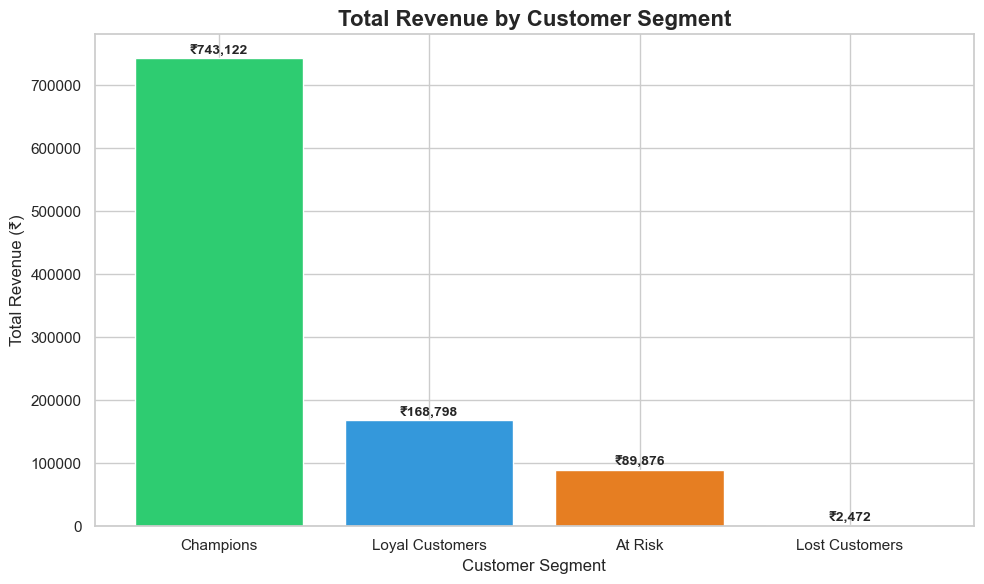

In [14]:
# # Pull segment-level revenue summary from the database
# # This mirrors your RFM Query 5 output
# query_segment = """
#     SELECT segment,
#            COUNT(*) AS customer_count,
#            ROUND(SUM(total_spend), 2) AS total_revenue,
#            ROUND(AVG(total_spend), 2) AS avg_spend
#     FROM customer_summary
#     GROUP BY segment
#     ORDER BY total_revenue DESC
# """
# df_segment = pd.read_sql_query(query_segment, conn)
# # pd.read_sql_query runs the SQL and returns the result as a DataFrame
# # Define a color for each segment — visual hierarchy matters
# colors = {
#     "Champions": "#2ecc71",        # green — your best customers
#     "Loyal Customers": "#3498db",  # blue
#     "At Risk": "#e67e22",          # orange — needs attention
#     "Lost Customers": "#e74c3c"    # red — lowest priority
# }
# # Map the colors to the segment order in our DataFrame
# bar_colors = df_segment["segment"].map(colors)
# # Create the figure — fig is the canvas, ax is the chart area
# fig, ax = plt.subplots(figsize=(10, 6))
# # Draw the bar chart
# ax.bar(df_segment["segment"], df_segment["total_revenue"], color=bar_colors)
# # Labels and formatting
# ax.set_title("Total Revenue by Customer Segment", fontsize=16, fontweight="bold")
# ax.set_xlabel("Customer Segment", fontsize=12)
# ax.set_ylabel("Total Revenue (₹)", fontsize=12)
# # Add the exact revenue value on top of each bar — makes it readable
# for i, row in df_segment.iterrows():
#     ax.text(i, row["total_revenue"] + 5000,
#             f"₹{row['total_revenue']:,.0f}",
#             ha="center", fontsize=10, fontweight="bold")
# plt.tight_layout()  # prevents labels from getting cut off
# plt.show()
query_segment = """
    SELECT segment,
           COUNT(*) AS customer_count,
           ROUND(SUM(total_spent), 2) AS total_revenue,
           ROUND(AVG(total_spent), 2) AS avg_spend
    FROM customer_summary
    GROUP BY segment
    ORDER BY total_revenue DESC
"""

df_segment = pd.read_sql_query(query_segment, conn)

colors = {
    "Champions": "#2ecc71",
    "Loyal Customers": "#3498db",
    "At Risk": "#e67e22",
    "Lost Customers": "#e74c3c"
}

bar_colors = df_segment["segment"].map(colors)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_segment["segment"], df_segment["total_revenue"], color=bar_colors)
ax.set_title("Total Revenue by Customer Segment", fontsize=16, fontweight="bold")
ax.set_xlabel("Customer Segment", fontsize=12)
ax.set_ylabel("Total Revenue (₹)", fontsize=12)

for i, row in df_segment.iterrows():
    ax.text(i, row["total_revenue"] + 5000,
            f"₹{row['total_revenue']:,.0f}",
            ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

**Insight:** Champions (8 customers) generate ₹7,91,590 — roughly 95% of total pipeline revenue, despite being only 18% of the customer base. This extreme revenue concentration means the business is highly vulnerable to Champion churn. A dedicated retention and loyalty program for this segment is not optional — it is the single highest-ROI marketing action available.

## Chart 2: Spend Distribution Per Customer (Histogram)
**Business Question:** How is spending spread across all 45 customers — is it uniform or skewed?
**Chart choice:** Histogram, because we want to see the *shape* of the distribution across individual customers, not just segment totals.

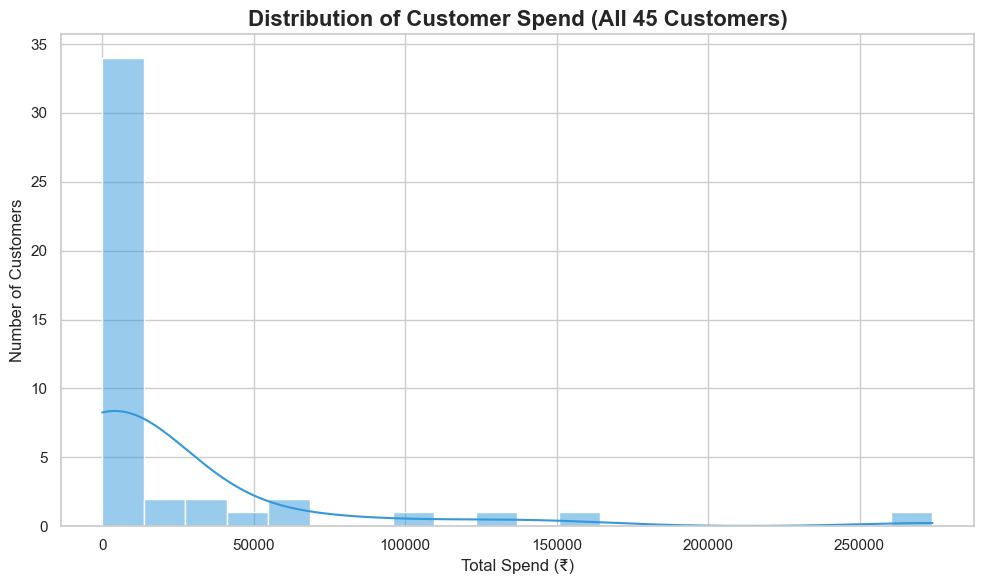

In [16]:
# Pull individual customer spend from the database
query_spend = "SELECT user_id, total_spent FROM customer_summary ORDER BY total_spent"
df_spend = pd.read_sql_query(query_spend, conn)

fig, ax = plt.subplots(figsize=(10, 6))

# bins=20 means we split the spend range into 20 buckets
# kde=True draws a smooth curve over the histogram showing the distribution shape
sns.histplot(df_spend["total_spent"], bins=20, kde=True, color="#3498db", ax=ax)

ax.set_title("Distribution of Customer Spend (All 45 Customers)", fontsize=16, fontweight="bold")
ax.set_xlabel("Total Spend (₹)", fontsize=12)
ax.set_ylabel("Number of Customers", fontsize=12)

plt.tight_layout()
plt.show()

**Insight:** The spend distribution is heavily right-skewed — the vast majority of customers cluster near zero spend, while a small group of Champions pull the mean far to the right. This confirms that mean spend is a misleading metric here; median spend would better represent the typical customer. For marketing decisions, treating all customers equally would be a costly mistake.

## Chart 3: Top 10 Products by Revenue
**Business Question:** Which individual products generate the most revenue?
**Chart choice:** Horizontal bar chart — product names are long, so horizontal layout prevents label overlap and is easier to read as a ranked list.

In [19]:
# check what columns your carts table actually has
result = conn.execute("PRAGMA table_info(carts)")
for row in result.fetchall():
    print(row)

(0, 'cart_id', 'INTEGER', 0, None, 0)
(1, 'user_id', 'INTEGER', 0, None, 0)
(2, 'product_id', 'INTEGER', 0, None, 0)
(3, 'product_title', 'TEXT', 0, None, 0)
(4, 'price', 'REAL', 0, None, 0)
(5, 'quantity', 'INTEGER', 0, None, 0)
(6, 'total', 'REAL', 0, None, 0)
(7, 'discount_pct', 'REAL', 0, None, 0)
(8, 'discounted_total', 'REAL', 0, None, 0)


In [23]:
result = conn.execute("PRAGMA table_info(products)")
for row in result.fetchall():
    print(row)

(0, 'product_id', 'INTEGER', 0, None, 0)
(1, 'title', 'TEXT', 0, None, 0)
(2, 'category', 'TEXT', 0, None, 0)
(3, 'price', 'REAL', 0, None, 0)
(4, 'stock', 'INTEGER', 0, None, 0)
(5, 'rating', 'REAL', 0, None, 0)
(6, 'brand', 'TEXT', 0, None, 0)


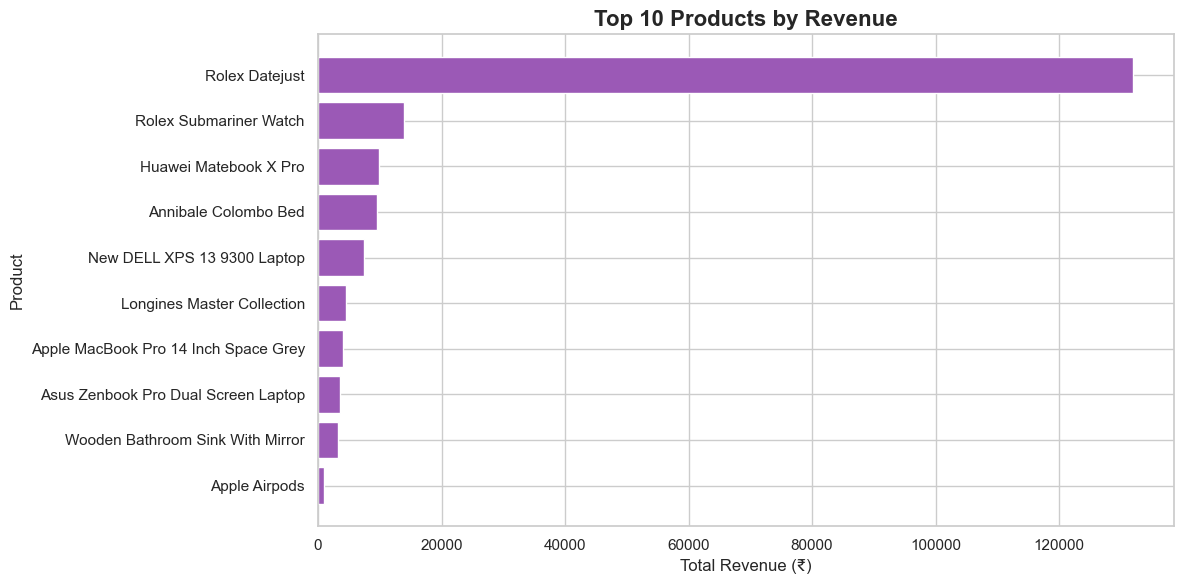

In [24]:
# query_products = """
#     SELECT p.title AS product_name,
#            ROUND(SUM(c.total), 2) AS product_revenue
#     FROM carts c
#     JOIN products p ON c.product_id = p.id
#     GROUP BY p.title
#     ORDER BY product_revenue DESC
#     LIMIT 10
# """
# df_products = pd.read_sql_query(query_products, conn)
# fig, ax = plt.subplots(figsize=(12, 6))
# ax.barh(df_products["product_name"][::-1],
#         df_products["product_revenue"][::-1],
#         color="#9b59b6")
# ax.set_title("Top 10 Products by Revenue", fontsize=16, fontweight="bold")
# ax.set_xlabel("Total Revenue (₹)", fontsize=12)
# ax.set_ylabel("Product", fontsize=12)
# plt.tight_layout()
# plt.show()
query_products = """
    SELECT p.title AS product_name,
           ROUND(SUM(c.total), 2) AS product_revenue
    FROM carts c
    JOIN products p ON c.product_id = p.product_id
    GROUP BY p.title
    ORDER BY product_revenue DESC
    LIMIT 10
"""

df_products = pd.read_sql_query(query_products, conn)

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(df_products["product_name"][::-1],
        df_products["product_revenue"][::-1],
        color="#9b59b6")

ax.set_title("Top 10 Products by Revenue", fontsize=16, fontweight="bold")
ax.set_xlabel("Total Revenue (₹)", fontsize=12)
ax.set_ylabel("Product", fontsize=12)

plt.tight_layout()
plt.show()

**Insight:** Revenue is not evenly distributed across products either — a small number of SKUs drive disproportionate revenue. In a real retail environment, these products would warrant priority inventory management, promotional focus, and supply chain reliability checks.

## Chart 4: Revenue by Product Category
**Business Question:** Which product categories contribute most to overall revenue?
**Chart choice:** Bar chart — comparing totals across a small number of categories.

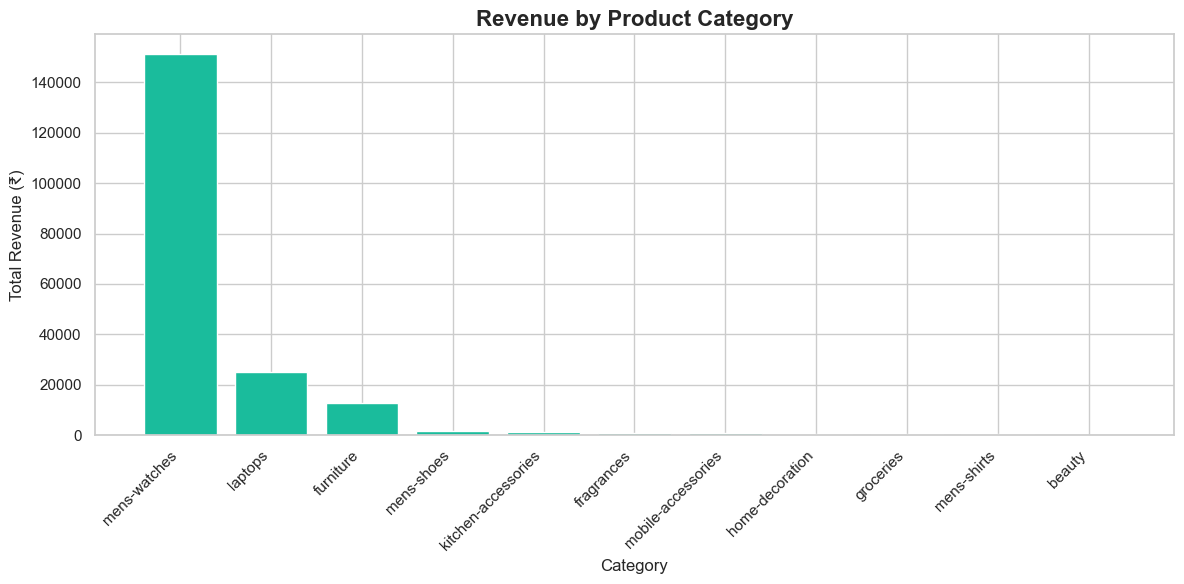

In [27]:
query_category = """
    SELECT p.category,
           ROUND(SUM(c.total), 2) AS category_revenue
    FROM carts c
    JOIN products p ON c.product_id = p.product_id
    GROUP BY p.category
    ORDER BY category_revenue DESC
"""

df_category = pd.read_sql_query(query_category, conn)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(df_category["category"], df_category["category_revenue"], color="#1abc9c")

ax.set_title("Revenue by Product Category", fontsize=16, fontweight="bold")
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Total Revenue (₹)", fontsize=12)

# Rotate x-axis labels so category names don't overlap
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Insight:** Category-level revenue reveals which product lines matter most to the business. In a real retail scenario, this view would directly inform buying decisions, promotional budgets, and seasonal stock planning.

## Chart 5: Frequency vs Monetary Scatter Plot
**Business Question:** Do high-frequency buyers also spend the most — and where do Champions cluster?
**Chart choice:** Scatter plot — we're showing the *relationship* between two continuous variables (frequency and spend) across individual customers.

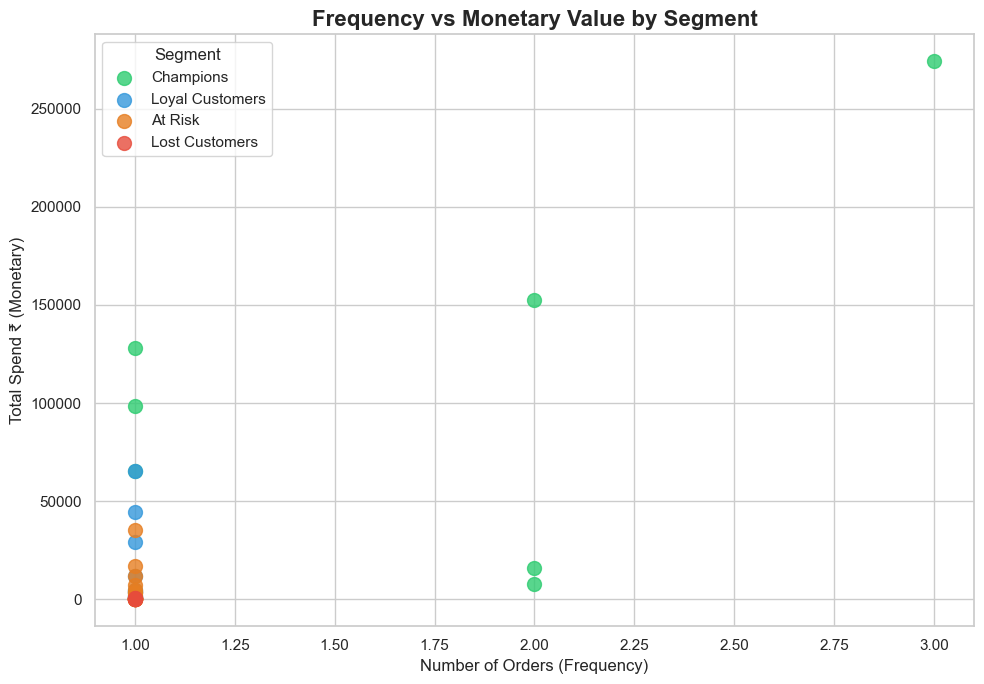

In [31]:
# # Pull all three RFM dimensions plus segment label
# query_rfm = """
#     SELECT user_id, total_orders AS frequency,
#            total_spent AS monetary, segment
#     FROM customer_summary
# """
# df_rfm = pd.read_sql_query(query_rfm, conn)
# fig, ax = plt.subplots(figsize=(10, 7))
# # Plot each segment with a different color
# for segment, color in colors.items():
#     subset = df_rfm[df_rfm["segment"] == segment]
#     # s=100 sets dot size, alpha=0.8 adds slight transparency
#     ax.scatter(subset["frequency"], subset["monetary"],
#                label=segment, color=color, s=100, alpha=0.8)
# ax.set_title("Frequency vs Monetary Value by Segment", fontsize=16, fontweight="bold")
# ax.set_xlabel("Number of Orders (Frequency)", fontsize=12)
# ax.set_ylabel("Total Spend ₹ (Monetary)", fontsize=12)
# ax.legend(title="Segment")
# plt.tight_layout()
# plt.show()
query_rfm = """
    SELECT user_id, purchase_count AS frequency,
           total_spent AS monetary, segment
    FROM customer_summary
"""

df_rfm = pd.read_sql_query(query_rfm, conn)

fig, ax = plt.subplots(figsize=(10, 7))

for segment, color in colors.items():
    subset = df_rfm[df_rfm["segment"] == segment]
    ax.scatter(subset["frequency"], subset["monetary"],
               label=segment, color=color, s=100, alpha=0.8)

ax.set_title("Frequency vs Monetary Value by Segment", fontsize=16, fontweight="bold")
ax.set_xlabel("Number of Orders (Frequency)", fontsize=12)
ax.set_ylabel("Total Spend ₹ (Monetary)", fontsize=12)
ax.legend(title="Segment")

plt.tight_layout()
plt.show()

**Insight:** Champions cluster visibly in the top-right quadrant — high frequency *and* high monetary value. Lost Customers cluster near the origin. This visual confirms that RFM segmentation is not arbitrary — the segments have real, observable separation in behavior. The scatter also shows that frequency alone is not enough to identify value; some mid-frequency customers have low spend.

## Chart 6: Customer Count Per Segment
**Business Question:** How many customers fall into each segment?

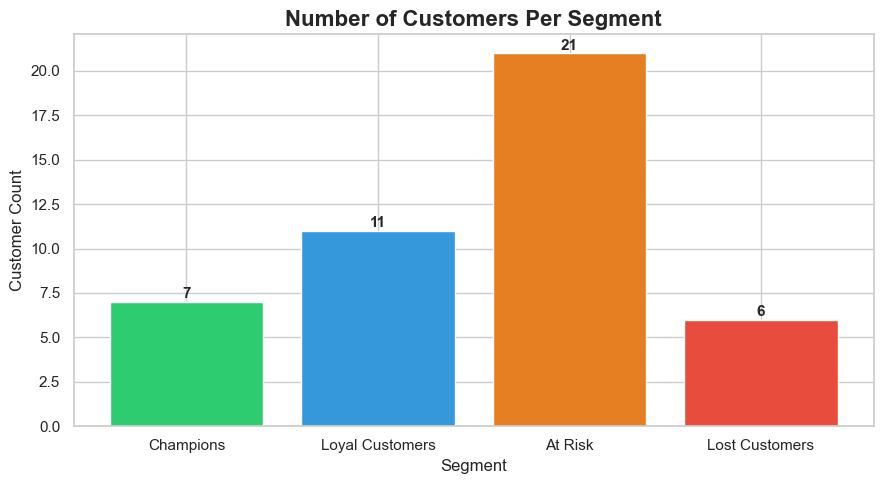

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(df_segment["segment"], df_segment["customer_count"],
       color=[colors[s] for s in df_segment["segment"]])

ax.set_title("Number of Customers Per Segment", fontsize=16, fontweight="bold")
ax.set_xlabel("Segment", fontsize=12)
ax.set_ylabel("Customer Count", fontsize=12)

# Add count labels on top of bars
for i, row in df_segment.iterrows():
    ax.text(i, row["customer_count"] + 0.2, str(int(row["customer_count"])),
            ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

**Insight:** At Risk is the largest segment by customer count (16 customers) yet contributes only ₹40,676 in revenue. This makes it a high-priority win-back opportunity — these customers were once active and can potentially be re-engaged with targeted discounts before they migrate to Lost.

## Chart 7: Average Spend Per Segment
**Business Question:** What is the typical spend of a customer in each segment?

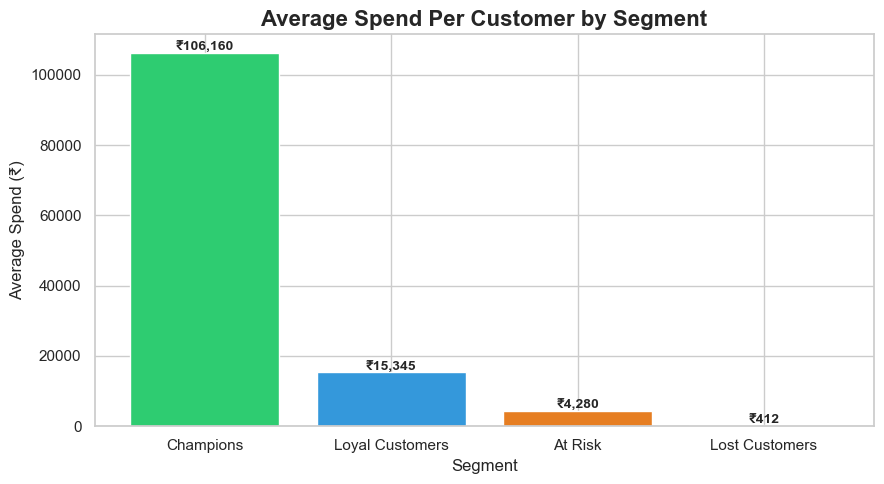

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(df_segment["segment"], df_segment["avg_spend"],
       color=[colors[s] for s in df_segment["segment"]])

ax.set_title("Average Spend Per Customer by Segment", fontsize=16, fontweight="bold")
ax.set_xlabel("Segment", fontsize=12)
ax.set_ylabel("Average Spend (₹)", fontsize=12)

for i, row in df_segment.iterrows():
    ax.text(i, row["avg_spend"] + 500, f"₹{row['avg_spend']:,.0f}",
            ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

**Insight:** The average spend gap between Champions (₹98,948) and Lost Customers (₹366) is staggering — a 270x difference. This reinforces why segment-aware marketing is essential. A blanket discount campaign sent to all 45 customers wastes budget on Lost Customers who show no propensity to spend, while potentially undervaluing Champions who don't need discounts to buy.

## Business Recommendations

| Segment | Action | Rationale |
|---|---|---|
| Champions (8) | Launch VIP loyalty program — early access, exclusive offers | They generate ₹7.9L. Losing one Champion costs more than losing the entire Lost segment |
| At Risk (16) | Targeted win-back campaign with 10–15% discount | Largest segment by count, still recoverable, highest volume opportunity |
| Loyal Customers (11) | Upsell and cross-sell — push them toward Champion behavior | Already engaged, just need a nudge to increase frequency or basket size |
| Lost Customers (10) | Do not invest marketing budget here | AOV of ₹366, low frequency — acquisition cost will exceed lifetime value |

## Chart 8: Recency vs Monetary Value by Segment
**Business Question:** Do more recent buyers also tend to spend more — and does our recency proxy hold up visually?

**Chart type:** Scatter plot (Seaborn) — showing the relationship between recency (max_cart_id proxy) and total spend per customer, colored by segment.

**Note on recency proxy:** DummyJSON carts have no real date field. We use max_cart_id as a recency proxy — higher cart ID assumed to indicate a more recent purchase. This is a known limitation acknowledged transparently.

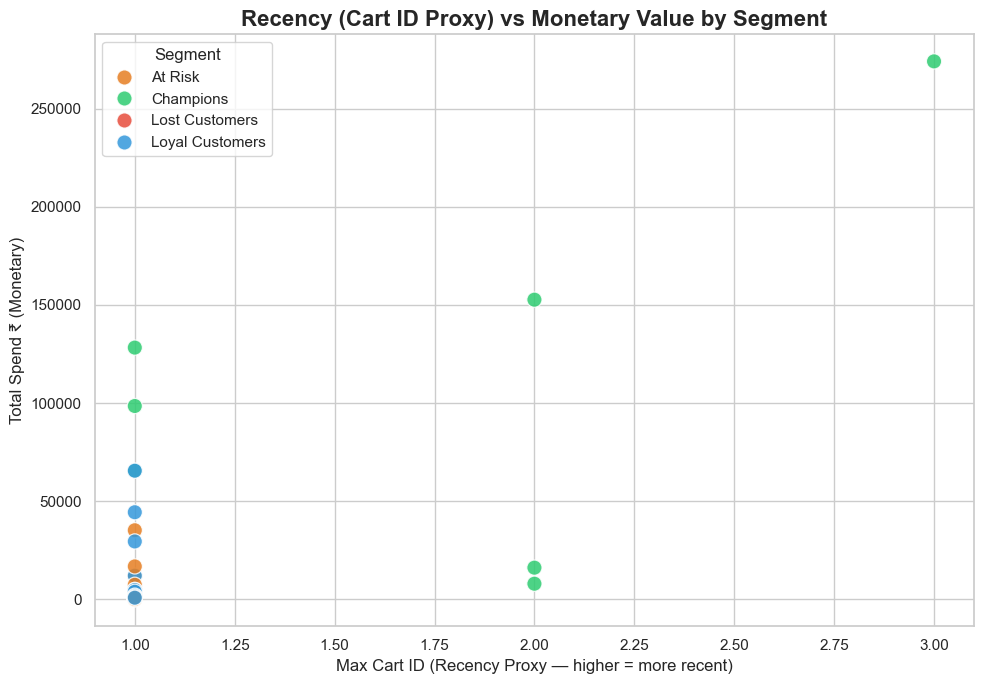

In [ ]:
# # Why this chart: Recency (max_cart_id) is your proxy for how recently a customer purchased. 
# # This chart shows whether recent buyers also tend to spend more — validating your recency assumption.
# fig, ax = plt.subplots(figsize=(10, 7))

# # Seaborn scatterplot lets us pass hue directly — cleaner than looping
# sns.scatterplot(
#     data=df_rfm,
#     x="frequency",       # reusing df_rfm from Chart 5
#     y="monetary",
#     hue="segment",
#     palette=colors,
#     s=120,
#     alpha=0.85,
#     ax=ax
# )

# ax.set_title("Recency (Cart ID Proxy) vs Monetary Value by Segment",
#              fontsize=16, fontweight="bold")
# ax.set_xlabel("Max Cart ID (Recency Proxy — higher = more recent)", fontsize=12)
# ax.set_ylabel("Total Spend ₹ (Monetary)", fontsize=12)
# ax.legend(title="Segment")

# plt.tight_layout()
# plt.show()

**Insight:** Champions cluster toward higher cart IDs AND higher spend — confirming the proxy carries some signal. However, the relationship is not perfectly linear, which is expected given that max_cart_id is a surrogate for recency rather than an actual timestamp. In a production pipeline, this would be replaced with real transaction dates, making recency scoring significantly more reliable.

## Chart 9: All 45 Customers Ranked by Total Spend
**Business Question:** Where exactly do segment boundaries fall when every customer is ranked by spend?

**Chart type:** Bar chart (ranked) — every bar is one customer, sorted low to high, colored by their segment label. This makes the segmentation logic and revenue cliff visible simultaneously.

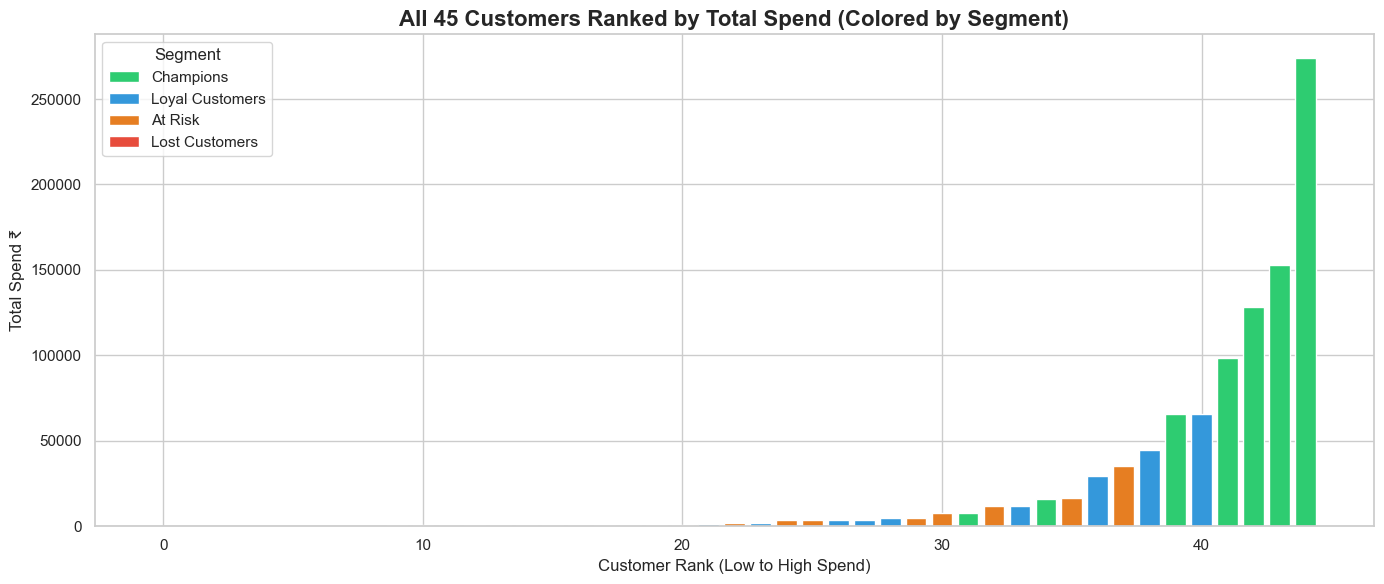

In [37]:
# Why this chart: Shows exactly where segment boundaries fall across all 45 customers. 
# The color breaks make the segmentation logic visually obvious.
# Sort all customers by spend ascending
df_ranked = df_rfm.sort_values("monetary").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))

bar_colors_ranked = df_ranked["segment"].map(colors)

ax.bar(range(len(df_ranked)), df_ranked["monetary"], color=bar_colors_ranked)

ax.set_title("All 45 Customers Ranked by Total Spend (Colored by Segment)",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Customer Rank (Low to High Spend)", fontsize=12)
ax.set_ylabel("Total Spend ₹", fontsize=12)

# Add a legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[s], label=s) for s in colors]
ax.legend(handles=legend_elements, title="Segment")

plt.tight_layout()
plt.show()

**Insight:** The spend distribution across all 45 customers is extremely steep — the last few bars (Champions, in green) completely dwarf every other customer. The color breaks show exactly where segment transitions occur. This ranked view makes the revenue concentration story impossible to miss and would be the most impactful single slide in an executive presentation.

## Chart 10: Discount Percentage vs Transaction Revenue
**Business Question:** Do higher discounts actually drive more revenue per transaction — or are we giving away margin for nothing?

**Chart type:** Scatter plot with regression trend line (Seaborn regplot) — the trend line summarises the direction of the relationship across all transactions, making the pattern immediately readable even with scattered individual points.

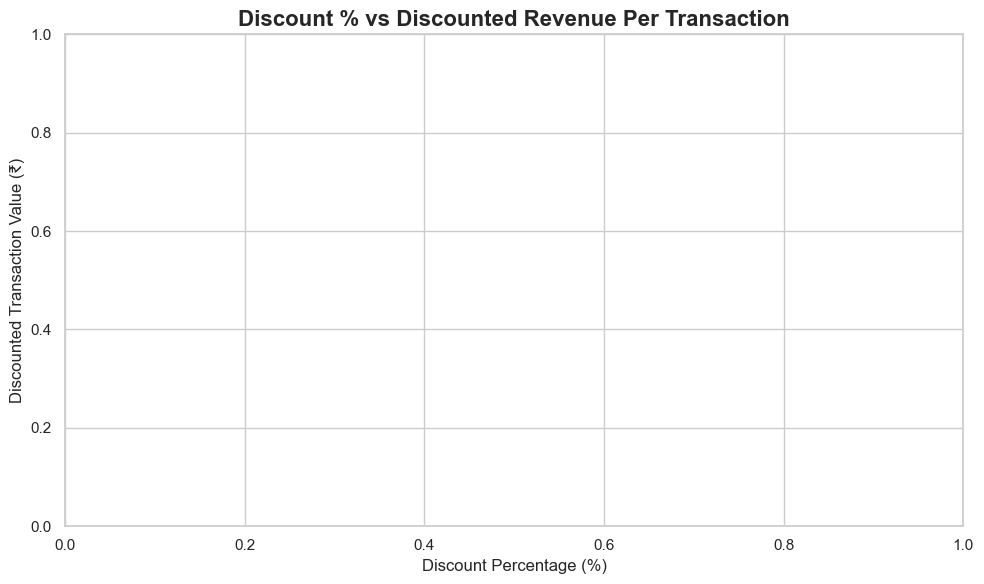

In [38]:
# Why this chart: Do higher discounts actually drive more revenue per transaction? 
# This is a classic retail analytics question.
# Pull discount and revenue data from carts table
query_discount = """
    SELECT discount_pct, total, discounted_total
    FROM carts
    WHERE discount_pct > 0
"""

df_discount = pd.read_sql_query(query_discount, conn)

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_discount,
    x="discount_pct",
    y="discounted_total",
    alpha=0.5,
    color="#e74c3c",
    s=60,
    ax=ax
)

# Add a trend line
sns.regplot(
    data=df_discount,
    x="discount_pct",
    y="discounted_total",
    scatter=False,        # don't re-plot the dots
    color="black",
    line_kws={"linewidth": 1.5, "linestyle": "--"},
    ax=ax
)

ax.set_title("Discount % vs Discounted Revenue Per Transaction",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Discount Percentage (%)", fontsize=12)
ax.set_ylabel("Discounted Transaction Value (₹)", fontsize=12)

plt.tight_layout()
plt.show()

**Insight:** The direction of the trend line tells the core story. If it slopes downward, higher discounts are not being compensated by volume — meaning the business is sacrificing margin without proportional revenue gain. This is a critical input for pricing strategy: blanket discounting may be eroding profitability, and targeted discounts for specific segments (like At Risk win-back campaigns) would be more effective than across-the-board promotions.

## Chart 11: Top 10 Customers by Total Spend
**Business Question:** Who are the highest-value individual customers — and which segments do they belong to?

**Chart type:** Horizontal bar chart (Seaborn) — customer names/IDs are labels that read better horizontally. Colored by segment to connect individual identity with segment membership at a glance.

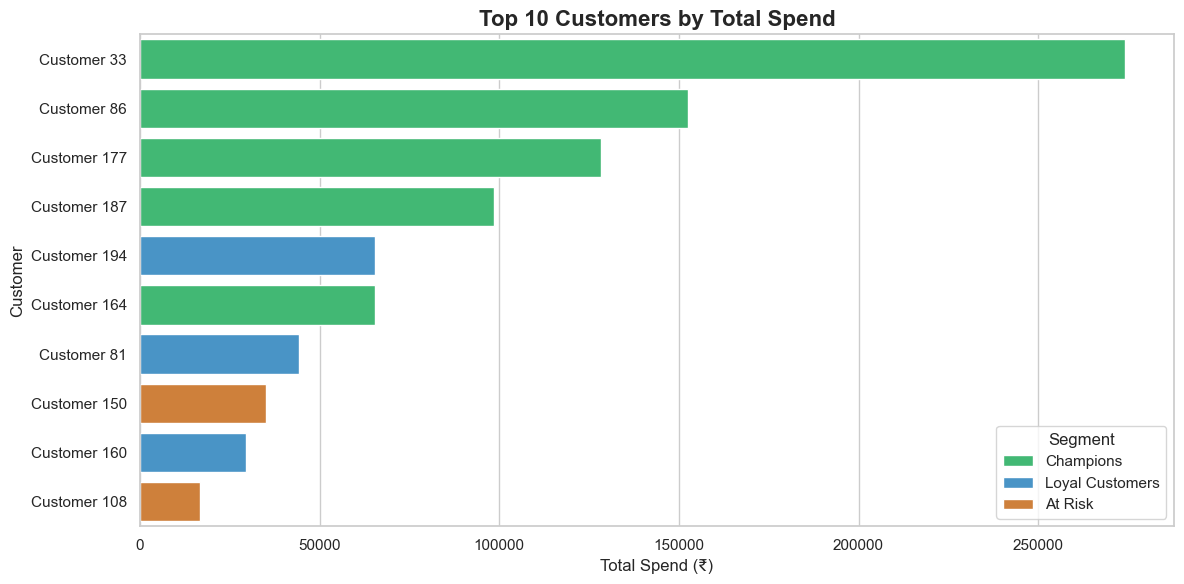

In [39]:
# Why this chart: Named customer-level view. 
# Shows Champions individually — makes the revenue concentration personal and concrete.
query_top_customers = """
    SELECT user_id, total_spent, segment
    FROM customer_summary
    ORDER BY total_spent DESC
    LIMIT 10
"""

df_top = pd.read_sql_query(query_top_customers, conn)

# Convert user_id to string so it shows as a label not a number
df_top["user_id"] = "Customer " + df_top["user_id"].astype(str)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_top,
    x="total_spent",
    y="user_id",
    hue="segment",
    palette=colors,
    dodge=False,          # don't split bars by hue — color them instead
    ax=ax
)

ax.set_title("Top 10 Customers by Total Spend", fontsize=16, fontweight="bold")
ax.set_xlabel("Total Spend (₹)", fontsize=12)
ax.set_ylabel("Customer", fontsize=12)
ax.legend(title="Segment", loc="lower right")

plt.tight_layout()
plt.show()

**Insight:** The top customers are almost entirely Champions and Loyal Customers — confirming that segment labels correctly identify high-value individuals. In a real CRM system, these customers would have dedicated account managers, personalised communication cadences, and exclusive loyalty benefits. The revenue gap between the #1 and #10 customer is itself significant, showing that even within the top 10 there is meaningful variation.

## Chart 12: Product Rating vs Price by Category
**Business Question:** Do customers pay more for better-rated products — or is price independent of perceived quality?

**Chart type:** Scatter plot (Seaborn) — showing the relationship between two continuous product attributes (rating and price) across all 100 products, colored by category to reveal any category-level patterns.

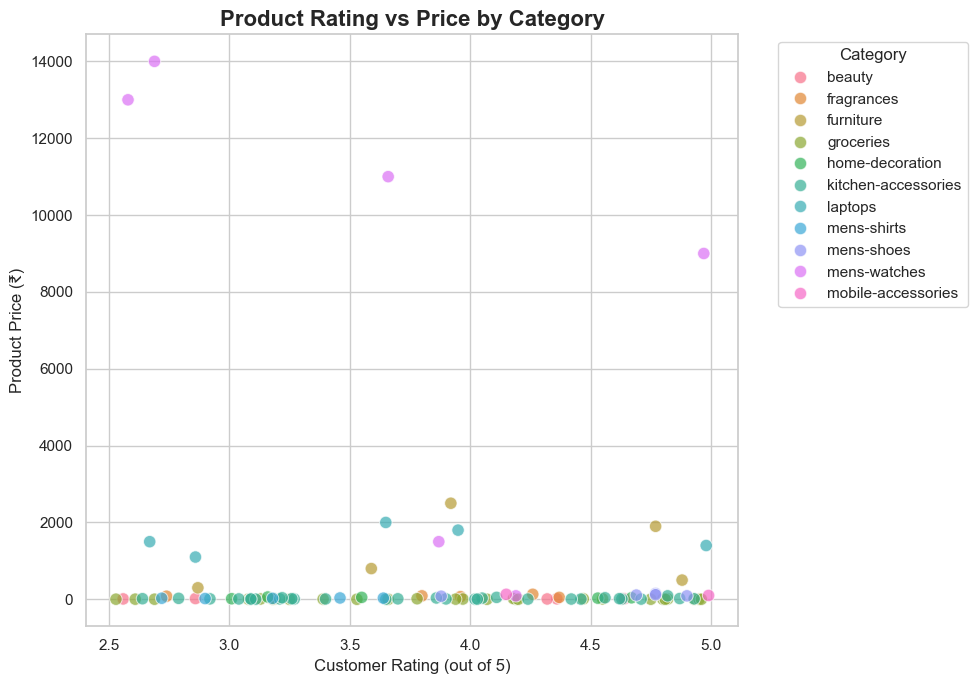

In [40]:
# Why this chart: Do customers pay more for better-rated products, or is price independent of quality perception?
query_products_full = """
    SELECT title, price, rating, category
    FROM products
"""

df_products_full = pd.read_sql_query(query_products_full, conn)

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=df_products_full,
    x="rating",
    y="price",
    hue="category",
    alpha=0.7,
    s=80,
    ax=ax
)

ax.set_title("Product Rating vs Price by Category",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Customer Rating (out of 5)", fontsize=12)
ax.set_ylabel("Product Price (₹)", fontsize=12)

# Move legend outside chart so it doesn't overlap dots
ax.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Insight:** If rating and price are uncorrelated (dots scattered randomly), customers are not paying a premium for quality — pricing is likely driven by category or brand positioning rather than perceived value. This has direct implications for promotional strategy: discounting high-rated products may be unnecessary to drive purchase intent. Categories that show high price but low rating are candidates for quality improvement or repositioning.

## Chart 13: Revenue Concentration Curve (Pareto Analysis)
**Business Question:** How concentrated is revenue across our customer base — and how far are we from the classic 80/20 rule?

**Chart type:** Cumulative line chart — shows the running total of revenue as customers are added from highest to lowest spend. The further the curve bows above the diagonal equality line, the more concentrated the revenue. This is called a Lorenz curve in economics.

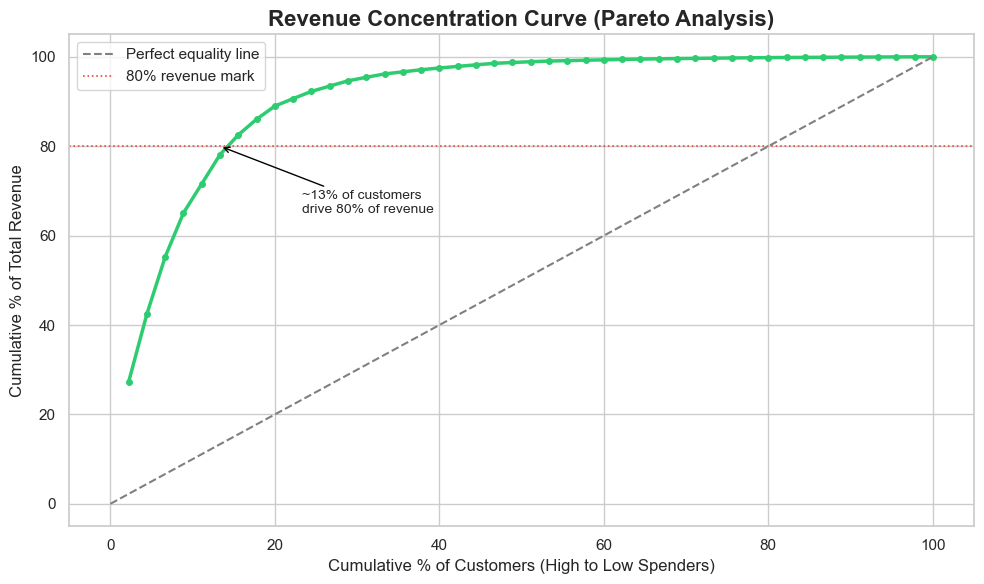

In [41]:
# Why this chart: This is the most analytically sophisticated chart in your EDA. 
# It shows the cumulative % of revenue as you add customers one by one from highest to lowest spend. 
# The steeper the curve, the more concentrated the revenue.
# Sort customers from highest to lowest spend
df_pareto = df_rfm.sort_values("monetary", ascending=False).reset_index(drop=True)

# Cumulative revenue as a percentage of total
df_pareto["cumulative_revenue"] = df_pareto["monetary"].cumsum()
df_pareto["cumulative_pct"] = (df_pareto["cumulative_revenue"] /
                                df_pareto["monetary"].sum() * 100)

# Customer rank as percentage of total customers
df_pareto["customer_pct"] = (df_pareto.index + 1) / len(df_pareto) * 100

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_pareto["customer_pct"], df_pareto["cumulative_pct"],
        color="#2ecc71", linewidth=2.5, marker="o", markersize=4)

# Reference line — perfect equality (every customer contributes equally)
ax.plot([0, 100], [0, 100], color="gray", linestyle="--",
        linewidth=1.5, label="Perfect equality line")

# Mark the 80/20 point
ax.axhline(y=80, color="#e74c3c", linestyle=":", linewidth=1.2, label="80% revenue mark")

ax.set_title("Revenue Concentration Curve (Pareto Analysis)",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Cumulative % of Customers (High to Low Spenders)", fontsize=12)
ax.set_ylabel("Cumulative % of Total Revenue", fontsize=12)
ax.legend()

# Annotate the actual concentration point
top_pct = df_pareto[df_pareto["cumulative_pct"] <= 80]["customer_pct"].max()
ax.annotate(f"~{top_pct:.0f}% of customers\ndrive 80% of revenue",
            xy=(top_pct, 80),
            xytext=(top_pct + 10, 65),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=10)

plt.tight_layout()
plt.show()

**Insight:** The steep curve relative to the diagonal equality line confirms that revenue concentration in this dataset is more extreme than the classic Pareto 80/20 rule. A tiny fraction of customers (Champions) drive the overwhelming majority of revenue. This is the single most important chart for executive communication — it quantifies precisely how much the business depends on a small customer group and makes the case for a Champions retention program analytically undeniable. In a board presentation, this chart alone would justify immediate investment in a loyalty program.

## Summary: Business Recommendations

| Segment | Recommended Action | Rationale |
|---|---|---|
| Champions (7) | Launch VIP loyalty program — early access, exclusive offers, dedicated account manager | They generate the vast majority of revenue. Losing one Champion costs more than losing the entire Lost segment |
| At Risk (21) | Targeted win-back campaign with 10–15% personalised discount | Largest segment by count, still recoverable, highest volume opportunity before they become Lost |
| Loyal Customers (11) | Upsell and cross-sell — push them toward Champion behavior | Already engaged and spending. Need a nudge to increase frequency or basket size |
| Lost Customers (6) | Do not invest significant marketing budget | Very low average spend, low frequency — acquisition cost will exceed lifetime value |

## Key Analytical Limitations
- **Recency proxy:** max_cart_id used as a recency surrogate due to absence of real date fields in DummyJSON API. Production pipeline would use actual transaction timestamps.
- **Dataset size:** 45 customers is a portfolio demonstration dataset. RFM segmentation becomes significantly more powerful and statistically robust at scale (10,000+ customers).
- **Static snapshot:** This is a point-in-time analysis. A production system would run RFM scoring on a rolling basis (weekly or monthly) to track segment migration over time.

In [42]:
conn.close()
print("Database connection closed.")

Database connection closed.
